In [87]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

import numpy as np
import os
import sys

In [88]:
print("Current working directory", os.getcwd() )
print("Directory contents:", os.listdir())

os.chdir("/Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project")
print("Current working directory", os.getcwd() )

Current working directory /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project
Directory contents: ['.DS_Store', 'requirements.txt', 'environment.yml', 'training', 'utils', 'models', 'test.py', 'explainability', 'README.md', 'results', '.gitignore', 'randomtestfile.py', 'evaluation', 'data_test.ipynb', '.git', 'process_all.py', 'main.py', 'data', 'notebooks', 'LICENCE', 'BCICIV_2a_gdf']
Current working directory /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from models.eegnet import EEGNet
from models.eenMLP import EEGMLP
from utils.loaders import get_dataloader
from utils.checks import check_shapes
from utils.preprocessing import preprocess_all_subjects

In [90]:
# ---------- Config ----------
subject_id = 8
batch_size = 32
epochs =150
lr = 0.0001
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


In [91]:
# ----------Re run the Preprocessing --------
preprocess_all_subjects(subject_ids=[1, 2, 3, 4, 5, 6, 7])

# ---------- Load Data ----------
dataset = get_dataloader(subject_ids=[1,2,3,4,5,6,7], return_dataset=True)
X, y = dataset.X, dataset.y
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"X dtype: {X.dtype}, y dtype: {y.dtype}")
print(f"y unique: {np.unique(y)}")
check_shapes(X, y)

# Ensure y is a NumPy array
y = np.array(y)

preprocessing subject 1 .....
Extracting EDF parameters from /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project/data/raw/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Users/temp/anaconda3/envs/robust_eeg/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: 22
['EEG-Fz', 'EEG-C3', 'EEG-Cz', 'EEG-C4', 'EEG-Pz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-6', 'EEG-7', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-15', 'EEG-16']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Event dict: {'102

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.4s finished


0 bad epochs dropped
preprocessing subject 2 .....
Extracting EDF parameters from /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project/data/raw/A02T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 677168  =      0.000 ...  2708.672 secs...


...

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: 22
['EEG-Fz', 'EEG-C3', 'EEG-Cz', 'EEG-C4', 'EEG-Pz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-6', 'EEG-7', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-15', 'EEG-16']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Event dict: {'102

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.3s finished
/Users/temp/anaconda3/envs/robust_eeg/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: 22
['EEG-Fz', 'EEG-C3', 'EEG-Cz', 'EEG-C4', 'EEG-Pz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-6', 'EEG-7', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-15', 'EEG-16']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Event dict: {'102

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.3s finished


Preprocessing complete
X shape: (2016, 22, 1001), y shape: (2016,)
X dtype: float64, y dtype: int64
y unique: [0 1 2 3]


In [92]:
# Filter out any invalid samples (e.g., negative class labels)
valid_mask = y >= 0
X = X[valid_mask]
y = y[valid_mask]

# Debug: Check what labels look like
print("Original labels:", np.unique(y), "min:", y.min(), "max:", y.max())

# Remap labels to start from 0
unique_labels = np.unique(y)
label_map = {old: new for new, old in enumerate(unique_labels)}
y = np.vectorize(label_map.get)(y)

print("Cleaned labels:", np.unique(y), "min:", y.min(), "max:", y.max())

Original labels: [0 1 2 3] min: 0 max: 3
Cleaned labels: [0 1 2 3] min: 0 max: 3


In [93]:
# ------------- Train test split -------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Toy dataset
X_small, y_small = [], []
for cls in range(4):
    idx = np.where(y == cls)[0][:30]
    X_small.append(X[idx])
    y_small.append(y[idx])

X_small = np.concatenate(X_small, axis=0)
y_small = np.concatenate(y_small, axis=0)

X_train = np.expand_dims(X_train, axis=1)    # from (N, 22, 1001) → (N, 1, 22, 1001)
X_val = np.expand_dims(X_val, axis=1)        # from (N, 22, 1001) → (N, 1, 22, 1001)

In [94]:
# asserting correct dimensions. good for debugging
assert X_train.shape[1] == 1, "Expected dummy input channel dimension (1)"
assert X_train.shape[2] == 22, "Expected 22 EEG channels"
assert X_train.shape[3] == 1001, "Expected 1001 time samples"
print(f"X shape: {X_small.shape}, y shape: {y_small.shape}")

X shape: (120, 22, 1001), y shape: (120,)


In [ ]:
# wrap in Dataloader
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)



In [ ]:
# ---------- Model Setup for EEGNet ----------
model = EEGNet(num_classes=len(torch.unique(torch.tensor(y))), channels=X.shape[1], samples=X.shape[2] ).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)


In [ ]:
train_losses = []
val_accuracies = []
best_val_acc = 0

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
           batch_X, batch_y = batch_X.to(device), batch_y.to(device) 
           outputs = model(batch_X)
           _, predicted = torch.max(outputs.data, 1)
           total += batch_y.size(0)
           correct += (predicted == batch_y).sum().item()
    
    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)
    
    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_loss:.4f} - Val Acc: {val_accuracy:.4f}")

print("✅ Training complete.")

Epoch [1/150] - Loss: 0.7802 - Val Acc: 0.4703
Epoch [2/150] - Loss: 0.7725 - Val Acc: 0.4530
Epoch [3/150] - Loss: 0.7724 - Val Acc: 0.4356
Epoch [4/150] - Loss: 0.7757 - Val Acc: 0.4505
Epoch [5/150] - Loss: 0.7628 - Val Acc: 0.4629
Epoch [6/150] - Loss: 0.7584 - Val Acc: 0.4678
Epoch [7/150] - Loss: 0.7538 - Val Acc: 0.4257
Epoch [8/150] - Loss: 0.7585 - Val Acc: 0.4282
Epoch [9/150] - Loss: 0.7554 - Val Acc: 0.4431
Epoch [10/150] - Loss: 0.7557 - Val Acc: 0.3713
Epoch [11/150] - Loss: 0.7457 - Val Acc: 0.4678
Epoch [12/150] - Loss: 0.7548 - Val Acc: 0.4579
Epoch [13/150] - Loss: 0.7488 - Val Acc: 0.4431
Epoch [14/150] - Loss: 0.7425 - Val Acc: 0.4480
Epoch [15/150] - Loss: 0.7387 - Val Acc: 0.4406
Epoch [16/150] - Loss: 0.7400 - Val Acc: 0.4455
Epoch [17/150] - Loss: 0.7407 - Val Acc: 0.4431
Epoch [18/150] - Loss: 0.7489 - Val Acc: 0.4629
Epoch [19/150] - Loss: 0.7314 - Val Acc: 0.4876
Epoch [20/150] - Loss: 0.7481 - Val Acc: 0.4554
Epoch [21/150] - Loss: 0.7195 - Val Acc: 0.4455
E

In [ ]:
# ADD THIS AFTER TRAINING IS DONE (for debugging the 81% mystery)
print("\n=== Debugging the 81% result ===")
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch_X, batch_y in val_loader:  # Same val_loader
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

final_check_acc = correct / total
print(f"Final check accuracy: {final_check_acc:.4f}")
print(f"Last training epoch accuracy: {val_accuracies[-1]:.4f}")
print(f"Difference: {abs(final_check_acc - val_accuracies[-1]):.4f}")


=== Debugging the 81% result ===
Final check accuracy: 0.4431
Last training epoch accuracy: 0.4431
Difference: 0.0000


In [ ]:
# --- Evaluation ---
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"\n✅ Final Val Accuracy: {acc:.4f}")


✅ Final Val Accuracy: 0.8170


In [99]:

print("Prediction distribution:", np.bincount(all_preds))
print(outputs[:5])  # see if they're all biased to class 0
probs = torch.softmax(outputs, dim=1)
print(probs[0])  # e.g., tensor([0.99, 0.002, 0.002, 0.001])


print("\n🧾 Classification Report:")
print(classification_report(all_labels, all_preds))

print("\n📊 Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Prediction distribution: [500 421 358 333]
tensor([[ 5.0346e-01, -3.0353e-01,  8.0470e-02, -7.4614e-01],
        [ 1.1918e-02,  1.1706e+00, -8.0532e-01, -3.6600e-01],
        [ 9.7022e-01,  3.0354e-01, -4.0740e-01, -1.0170e+00],
        [ 4.9573e-01, -8.0390e-02, -2.7790e-01, -5.3525e-01],
        [ 1.4419e-03, -2.0189e+00,  1.4868e+00, -2.0029e+00]], device='mps:0')
tensor([0.4188, 0.1869, 0.2743, 0.1200], device='mps:0')

🧾 Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.89      0.79       403
           1       0.82      0.85      0.83       403
           2       0.88      0.78      0.83       403
           3       0.90      0.74      0.82       403

    accuracy                           0.82      1612
   macro avg       0.83      0.82      0.82      1612
weighted avg       0.83      0.82      0.82      1612


📊 Confusion Matrix:
[[357  21  13  12]
 [ 44 344   8   7]
 [ 49  24 316  14]
 [ 50  32  21 300]]


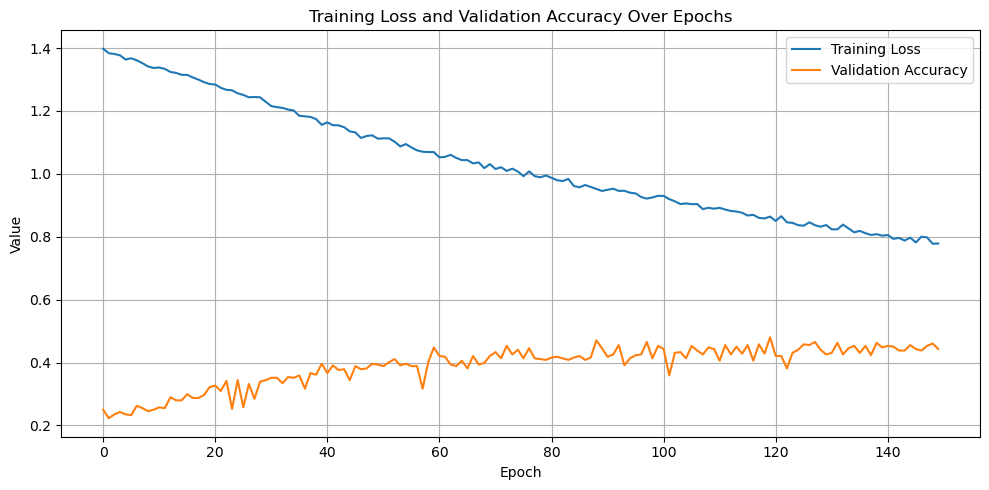

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Training Loss and Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("results/training_loss_val_accuracy.png")
plt.show()


##Observation 
This is the result of Overfittiing, Much like what Dr Zhang had suggested 
Likely that models are too large.


In [35]:
# print state dict of model 
print("Model's state_dict: ")
for param in model.state_dict():
    print(param, '\t', model.state_dict()[param].size()) 



Model's state_dict: 
firstconv.0.weight 	 torch.Size([16, 1, 1, 51])
firstconv.1.weight 	 torch.Size([16])
firstconv.1.bias 	 torch.Size([16])
firstconv.1.running_mean 	 torch.Size([16])
firstconv.1.running_var 	 torch.Size([16])
firstconv.1.num_batches_tracked 	 torch.Size([])
depthwiseConv.0.weight 	 torch.Size([32, 1, 22, 1])
depthwiseConv.1.weight 	 torch.Size([32])
depthwiseConv.1.bias 	 torch.Size([32])
depthwiseConv.1.running_mean 	 torch.Size([32])
depthwiseConv.1.running_var 	 torch.Size([32])
depthwiseConv.1.num_batches_tracked 	 torch.Size([])
separableConv.0.weight 	 torch.Size([32, 32, 1, 15])
separableConv.1.weight 	 torch.Size([32])
separableConv.1.bias 	 torch.Size([32])
separableConv.1.running_mean 	 torch.Size([32])
separableConv.1.running_var 	 torch.Size([32])
separableConv.1.num_batches_tracked 	 torch.Size([])
classify.weight 	 torch.Size([4, 992])
classify.bias 	 torch.Size([4])


In [36]:
# Print optimizer's state_dict
print("Optimizer's state_dict:")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

Optimizer's state_dict:
state 	 {0: {'step': tensor(5100.), 'exp_avg': tensor([[[[ 4.7005e-03,  5.7887e-03,  5.8638e-03,  5.3002e-03,  4.5148e-03,
            3.8368e-03,  3.2662e-03,  2.8060e-03,  2.2143e-03,  1.2855e-03,
            4.3442e-05, -1.5658e-03, -3.3952e-03, -5.2361e-03, -6.8579e-03,
           -8.1054e-03, -8.7530e-03, -8.6300e-03, -7.7240e-03, -6.1381e-03,
           -4.0918e-03, -1.8762e-03,  1.8084e-04,  2.0290e-03,  3.6347e-03,
            5.0525e-03,  6.3875e-03,  7.5343e-03,  8.3488e-03,  8.6339e-03,
            8.2271e-03,  7.0515e-03,  5.2249e-03,  2.9442e-03,  4.8682e-04,
           -1.8285e-03, -3.7964e-03, -5.2300e-03, -6.0394e-03, -6.2939e-03,
           -6.1383e-03, -5.7176e-03, -5.1620e-03, -4.5185e-03, -3.7416e-03,
           -2.7511e-03, -1.4980e-03, -1.0608e-04,  1.3021e-03,  2.4250e-03,
            3.0118e-03]]],


        [[[-1.1619e-03, -1.4172e-03, -1.6599e-03, -1.7936e-03, -1.7403e-03,
           -1.4588e-03, -9.7796e-04, -3.2386e-04,  4.4417e-04,  

In [59]:
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save model state dict (this is the recommended way)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch,
    'accuracy': val_accuracy,
    'loss': loss
}, 'models/eegnet_checkpoint.pth')

Activation shape: (12, 16, 22, 1001)


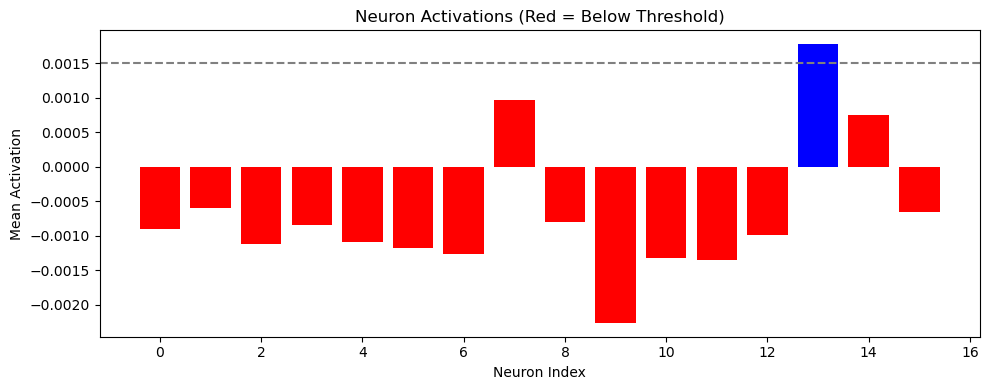

In [62]:
# plotting the activation under a certain threshold given a specific layer. 

activations = []

def hook_fn(module, input, output):
    activations.append(output.detach().cpu())

# Register hook to a specific layer (e.g., model.features[0])
hook = model.firstconv.register_forward_hook(hook_fn)

# Forward pass on a batch
model.eval()
with torch.no_grad():
    _ = model(batch_X)

# Remove hook
hook.remove()


acts = activations[0].numpy()  # Shape: (batch_size, channels, H, W)
print("Activation shape:", acts.shape)


# Convert to NumPy
acts = activations[0].numpy()  # shape: (batch_size, channels, H, W)

# Aggregate (e.g., mean over spatial dimensions and batch)
mean_acts = acts.mean(axis=(0, 2, 3))

# Plot neurons below a threshold
threshold = 0.0015
low_activating = mean_acts < threshold

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(range(len(mean_acts)), mean_acts, color=["red" if low else "blue" for low in low_activating])
plt.axhline(y=threshold, color="gray", linestyle="--")
plt.title("Neuron Activations (Red = Below Threshold)")
plt.xlabel("Neuron Index")
plt.ylabel("Mean Activation")
plt.tight_layout()
plt.show()


In [63]:
# Registering the hooks for ease of use 

def save_hook(name):
    def hook(module, input, output):
        print(f"Captured {name} with shape {output.shape}")
        activations[name] = output.detach().cpu()
    return hook

activations = {}

# Register hooks
model.firstconv.register_forward_hook(save_hook("firstconv"))
model.depthwiseConv.register_forward_hook(save_hook("depthwise"))
model.separableConv.register_forward_hook(save_hook("separable"))


In [64]:
model.eval()
batch_X, batch_y = next(iter(train_loader))
batch_X = batch_X.to(device)

with torch.no_grad():
    outputs = model(batch_X)


Captured firstconv with shape torch.Size([32, 16, 22, 1001])
Captured depthwise with shape torch.Size([32, 32, 1, 250])
Captured separable with shape torch.Size([32, 32, 1, 31])


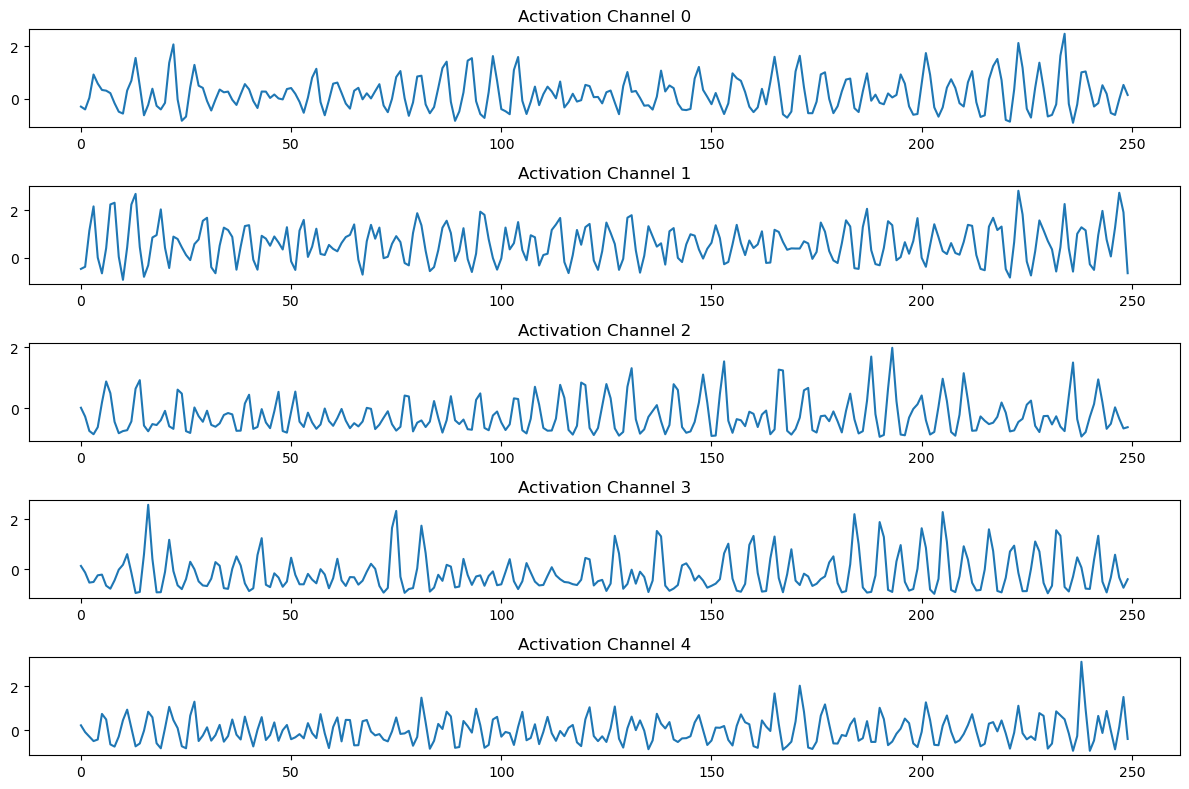

In [22]:
    
# plotting the first five channels of the layers in our eegnet. for each layer/ 

# Example: plot first 5 channels from 'firstconv'
act = activations['depthwise'][0]  # shape: (channels, 1, time)

fig, axs = plt.subplots(5, 1, figsize=(12, 8))
for i in range(5):
    axs[i].plot(act[i][0])  # [0] to remove singleton spatial dim
    axs[i].set_title(f'Activation Channel {i}')
plt.tight_layout()
plt.show()



In [23]:
def plot_activation(activation, layer_name, threshold=None):
    """
    activation: torch.Tensor (batch_size, channels, height, width)
    layer_name: str
    threshold: float or None (set a cutoff if you want)
    """
    # Take first batch item
    act = activation[0]
    # Take mean across time (height dimension) if needed
    mean_act = act.mean(dim=-1)  # shape: (channels, feature maps)

    plt.figure(figsize=(12,4))
    for i, ch in enumerate(mean_act):
        if threshold is None or ch.max() > threshold:
            plt.plot(ch.numpy(), label=f"channel {i}")
    plt.title(f"Activations from {layer_name}")
    plt.xlabel("feature map dimension")
    plt.ylabel("mean activation")
    plt.legend()
    plt.show()


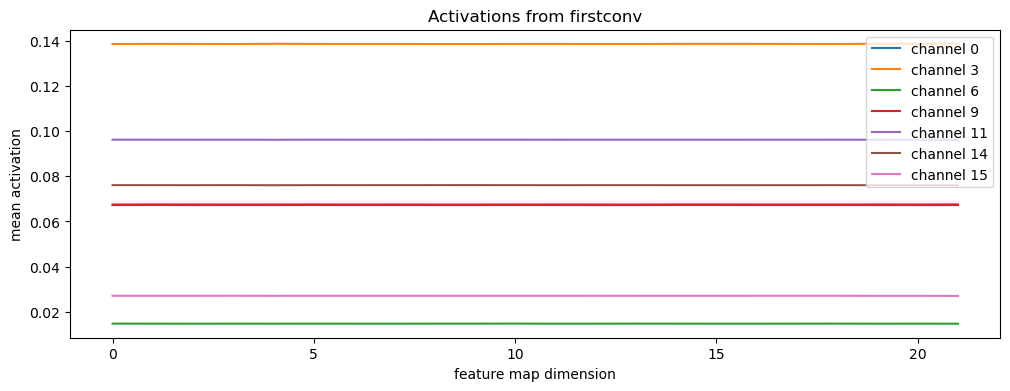

In [24]:
plot_activation(model.activations['firstconv'], layer_name="firstconv", threshold=0.001)


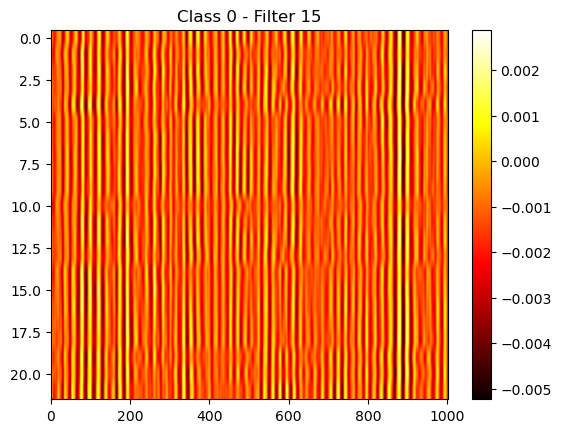

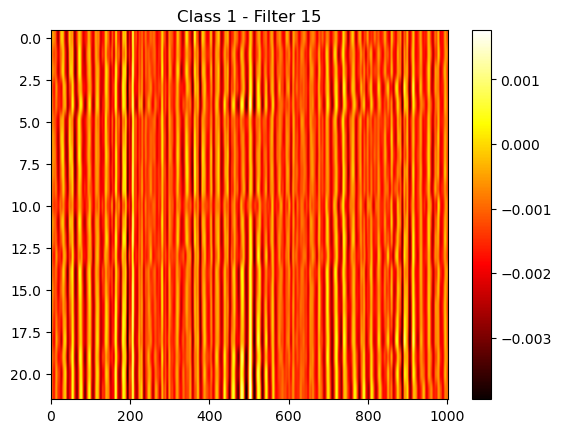

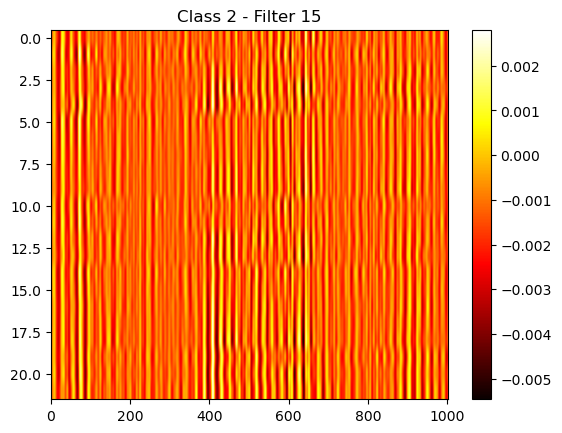

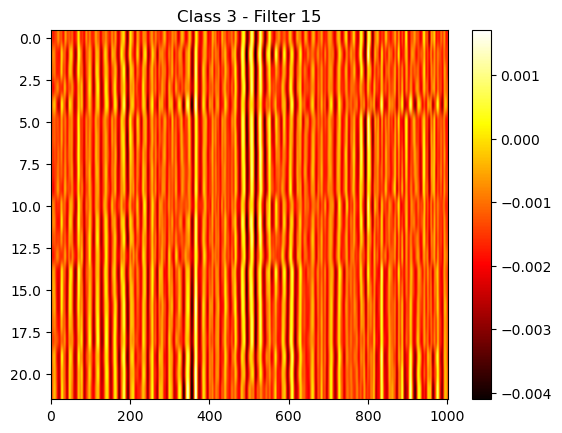

In [65]:
acts = model.activations['firstconv']  # (N, 16, 22, something)
labels = batch_y.numpy()

for cls in np.unique(labels):
    idxs = np.where(labels == cls)[0]
    mean_act = acts[idxs].mean(dim=0)  # average over samples of that class
    # plot a filter heatmap for the first filter:
    plt.imshow(mean_act[6], aspect="auto", cmap="hot")
    plt.title(f"Class {cls} - Filter 15")
    plt.colorbar()
    plt.show()


In [66]:
# ================
# CLASS 0 FILTER PLOTS
# ================
model.eval()

# use the same data as training (or you can use X_val if you have it)
class_idx = 0

# Filter samples for class 0
X_class0 = X[y == class_idx]
X_class0 = torch.tensor(X_class0, dtype=torch.float32).unsqueeze(1).to(device)
# shape [N_samples_class0, 1, 22, 1001]

# pass through first conv layer only
with torch.no_grad():
    first_layer = model.firstconv
    activations = first_layer(X_class0)
    # shape [N_samples_class0, n_filters, 22, time]

# take the mean over the samples
mean_activations = activations.mean(dim=0)  # shape [n_filters, 22, time]

# loop through each filter
for i in range(mean_activations.shape[0]):
    plt.figure(figsize=(12,6))
    plt.imshow(mean_activations[i].cpu(), 
               aspect='auto', 
               cmap='hot')
    plt.colorbar()
    plt.title(f"Class 0 - Filter {i}")
    plt.xlabel("Time")
    plt.ylabel("Channel")
    plt.tight_layout()
    plt.close()


Captured firstconv with shape torch.Size([504, 16, 22, 1001])


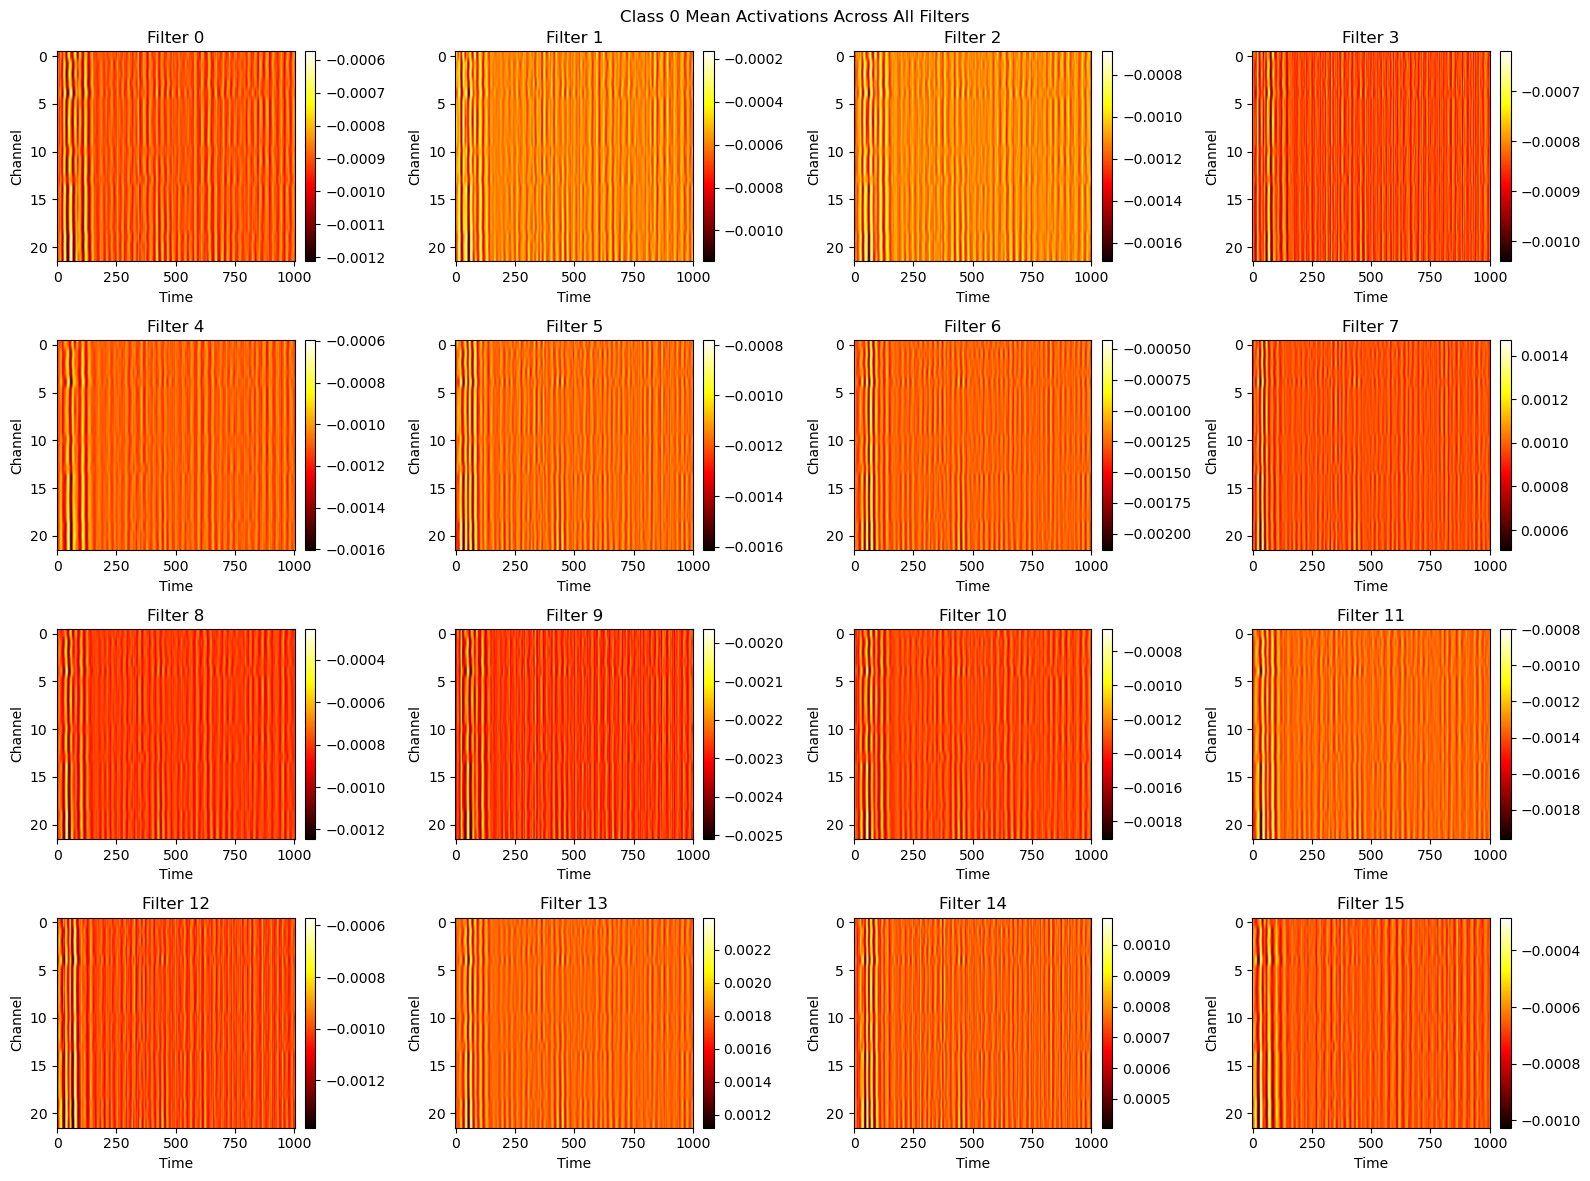

In [67]:

n_filters = mean_activations.shape[0]

# calculate rows/cols to plot in a square grid
n_cols = 4
n_rows = (n_filters + n_cols - 1) // n_cols

plt.figure(figsize=(4*n_cols, 3*n_rows))

for i in range(n_filters):
    ax = plt.subplot(n_rows, n_cols, i+1)
    img = ax.imshow(mean_activations[i].cpu(), aspect='auto', cmap='hot')
    ax.set_title(f"Filter {i}")
    plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel("Time")
    ax.set_ylabel("Channel")

plt.suptitle("Class 0 Mean Activations Across All Filters")
plt.tight_layout()
plt.savefig("results/class0_all_filters.png")
plt.show()


(1, 22, 1001)


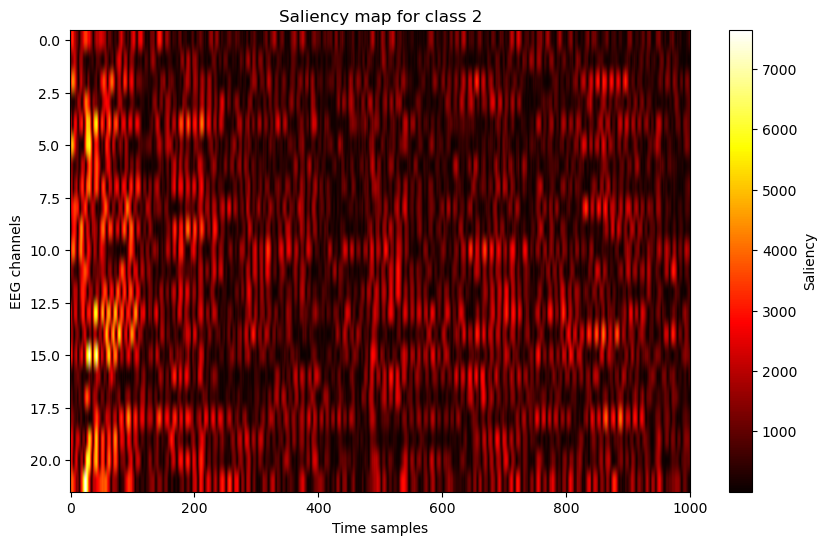

In [86]:
import torch

model.eval()

# get a sample (say, 1 
# trial)
sample_X = torch.tensor(X_val[0:1], dtype=torch.float32).to(device)
sample_X.requires_grad = True  # key step

output = model(sample_X)
predicted_class = output.argmax(dim=1)

# if you want saliency for predicted class:
score = output[0, predicted_class]
score.backward()

# saliency is the absolute gradient
saliency = sample_X.grad.detach().abs().cpu().numpy()[0]

print(saliency.shape)  # should be (1, channels, time)

# plot it
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.imshow(saliency[0], aspect='auto', cmap='hot')
plt.colorbar(label="Saliency")
plt.xlabel("Time samples")
plt.ylabel("EEG channels")
plt.title(f"Saliency map for class {predicted_class.item()}")
plt.show()
